In [26]:
from sklearn.model_selection import train_test_split, StratifiedKFold,GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,precision_score, recall_score, f1_score ,average_precision_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(r"E:\Work\AI\MAKTAB\HW-CW-S02\Mini_Project_01\data\Cleaned_data.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [27]:
x_train,x_test,y_train,y_test=train_test_split(df.iloc[:, :-1],df.iloc[:, -1],stratify=df.iloc[:, -1],test_size=0.2,random_state=42)

In [28]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)

Logistic Regression Accuracy: 0.9991
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.85      0.58      0.69        95

    accuracy                           1.00     56746
   macro avg       0.92      0.79      0.84     56746
weighted avg       1.00      1.00      1.00     56746

Decision Tree Accuracy: 0.9990
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.72      0.68      0.70        95

    accuracy                           1.00     56746
   macro avg       0.86      0.84      0.85     56746
weighted avg       1.00      1.00      1.00     56746

K-Nearest Neighbors Accuracy: 0.9995
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.94      0.72      0.81        95

    accuracy                           1.00     56746
   macro avg       0.97

<Axes: >

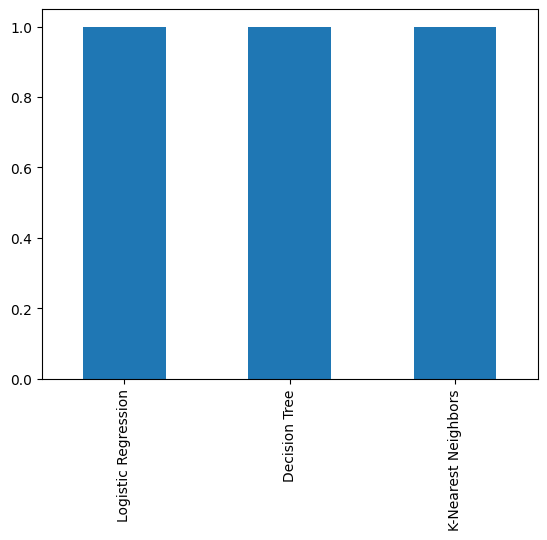

In [29]:
models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=3)}
model_results = {}
for model_name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    model_results[model_name] = accuracy
    print(f"{model_name} Accuracy: {accuracy:.4f}")
    print(classification_report(y_test, y_pred))

pd.DataFrame(model_results, index=['Accuracy']).T.plot(kind='bar', legend=False)

In [30]:
k=[1,5,20]
for i in k:
    model = KNeighborsClassifier(n_neighbors=i)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"KNN with k={i} Accuracy: {accuracy:.4f}")
    print(classification_report(y_test, y_pred))

KNN with k=1 Accuracy: 0.9993
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.83      0.72      0.77        95

    accuracy                           1.00     56746
   macro avg       0.91      0.86      0.88     56746
weighted avg       1.00      1.00      1.00     56746

KNN with k=5 Accuracy: 0.9994
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.96      0.68      0.80        95

    accuracy                           1.00     56746
   macro avg       0.98      0.84      0.90     56746
weighted avg       1.00      1.00      1.00     56746

KNN with k=20 Accuracy: 0.9994
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.92      0.68      0.78        95

    accuracy                           1.00     56746
   macro avg       0.96      0.84    

In [31]:
depth=[2,5,10,None]
precision_scores_dt = []
recall_scores_dt = []
f1_scores_dt = []
for d in depth:
    model = DecisionTreeClassifier(max_depth=d)
    model.fit(x_train, y_train)
    y_pred_train = model.predict(x_train)
    y_pred_test = model.predict(x_test)
    accuracy_train = accuracy_score(y_train, y_pred_train)
    accuracy_test = accuracy_score(y_test, y_pred_test)
    precision = precision_score(y_test, y_pred_test)
    recall = recall_score(y_test, y_pred_test)
    f1 = f1_score(y_test, y_pred_test)
    precision_scores_dt.append(precision)
    recall_scores_dt.append(recall)
    f1_scores_dt.append(f1)
    print(f"Training Accuracy: {accuracy_train:.4f}")
    print(f"Testing Accuracy: {accuracy_test:.4f}")
    print(classification_report(y_test, y_pred_test))

Training Accuracy: 0.9993
Testing Accuracy: 0.9993
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.84      0.69      0.76        95

    accuracy                           1.00     56746
   macro avg       0.92      0.85      0.88     56746
weighted avg       1.00      1.00      1.00     56746

Training Accuracy: 0.9996
Testing Accuracy: 0.9993
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.87      0.71      0.78        95

    accuracy                           1.00     56746
   macro avg       0.93      0.85      0.89     56746
weighted avg       1.00      1.00      1.00     56746

Training Accuracy: 0.9998
Testing Accuracy: 0.9993
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.88      0.71      0.78        95

    accuracy                 

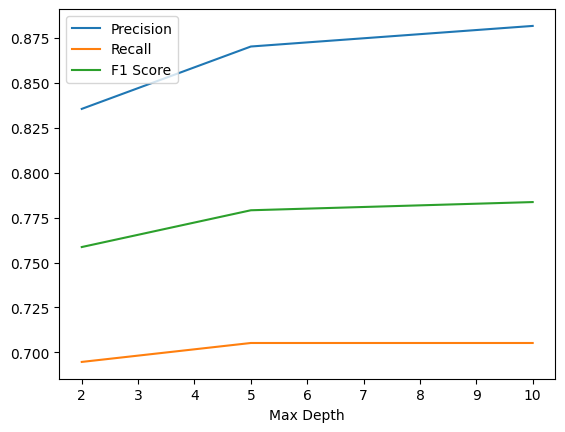

In [32]:
report_dt=pd.DataFrame({'Max Depth':depth,'Precision':precision_scores_dt,'Recall':recall_scores_dt,'F1 Score':f1_scores_dt})
report_dt.plot(x='Max Depth', y=['Precision', 'Recall', 'F1 Score'])
plt.show()

In [33]:
threshold=[0.3,0.5,0.7]
precision_scores = []
recall_scores = []
f1_scores = []
for i in threshold:
    model = LogisticRegression()
    model.fit(X_train_scaled, y_train)
    y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]
    y_pred = (y_pred_prob >= i).astype(int)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    precision_scores.append(precision)
    recall_scores.append(recall)
    f1_scores.append(f1)
    print(f"Logistic Regression with threshold={i} Accuracy: {accuracy:.4f}")
    print(classification_report(y_test, y_pred))


Logistic Regression with threshold=0.3 Accuracy: 0.9992
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.84      0.64      0.73        95

    accuracy                           1.00     56746
   macro avg       0.92      0.82      0.86     56746
weighted avg       1.00      1.00      1.00     56746

Logistic Regression with threshold=0.5 Accuracy: 0.9991
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.85      0.58      0.69        95

    accuracy                           1.00     56746
   macro avg       0.92      0.79      0.84     56746
weighted avg       1.00      1.00      1.00     56746

Logistic Regression with threshold=0.7 Accuracy: 0.9990
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.84      0.52      0.64        95

    accuracy  

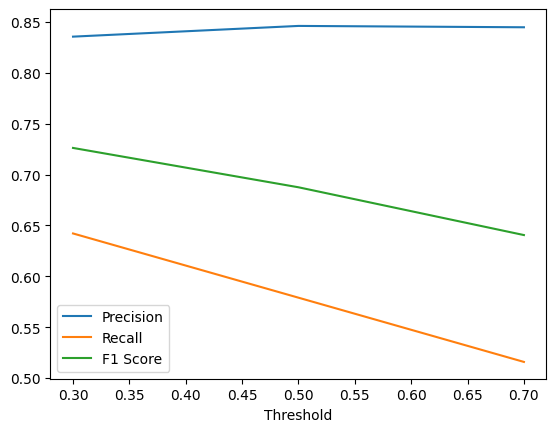

In [34]:
report_logestic=pd.DataFrame({'Threshold':threshold,'Precision':precision_scores,'Recall':recall_scores,'F1 Score':f1_scores})
report_logestic.plot(x='Threshold', y=['Precision', 'Recall', 'F1 Score'])
plt.show()

In [35]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid={
        'max_depth': [3, 5, 8, 10, 15, 20, None],
        'min_samples_split': [2, 5, 10, 20],
        'min_samples_leaf': [1, 2, 5, 10]
    },
    cv=cv,
    scoring='f1',
    n_jobs=1
)

grid_dt.fit(x_train, y_train)

print("Best parameters:", grid_dt.best_params_)
print("Best CV F1:", grid_dt.best_score_)

Best parameters: {'max_depth': 8, 'min_samples_leaf': 5, 'min_samples_split': 20}
Best CV F1: 0.8366470866140899


In [36]:
model_dt=grid_dt.best_estimator_
y_pred_dt = model_dt.predict(x_test)

print(classification_report(y_test, y_pred_dt))
print(confusion_matrix(y_test,y_pred_dt))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.92      0.71      0.80        95

    accuracy                           1.00     56746
   macro avg       0.96      0.85      0.90     56746
weighted avg       1.00      1.00      1.00     56746

[[56645     6]
 [   28    67]]


In [37]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid={
        'C': [0.01, 0.1, 1, 10, 100],
        'class_weight': [None, 'balanced']
    },
    cv=cv,
    scoring='f1',
    n_jobs=1
)

grid_lr.fit(X_train_scaled, y_train)

print("Best parameters:", grid_lr.best_params_)
print("Best CV F1:", grid_lr.best_score_)

Best parameters: {'C': 10, 'class_weight': None}
Best CV F1: 0.7118034865648862


In [38]:
model_lr=grid_lr.best_estimator_
y_pred_lr = model_lr.predict(X_test_scaled)

print(classification_report(y_test, y_pred_lr))
print(confusion_matrix(y_test,y_pred_lr))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.85      0.58      0.69        95

    accuracy                           1.00     56746
   macro avg       0.92      0.79      0.84     56746
weighted avg       1.00      1.00      1.00     56746

[[56641    10]
 [   40    55]]


In [39]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid={
        'n_neighbors': [3, 5, 7, 9, 11, 15, 20, 25, 30],
        'weights': ['uniform', 'distance'],
        'p': [1, 2]
    },
    cv=cv,
    scoring='f1',
    n_jobs=1
)

grid_knn.fit(X_train_scaled, y_train)

print("Best parameters:", grid_knn.best_params_)
print("Best CV F1:", grid_knn.best_score_)

Best parameters: {'n_neighbors': 3, 'p': 1, 'weights': 'distance'}
Best CV F1: 0.8542856661803029


In [40]:
model_knn = grid_knn.best_estimator_

y_pred_knn = model_knn.predict(X_test_scaled)

print(classification_report(y_test, y_pred_knn))
print(confusion_matrix(y_test,y_pred_knn))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.96      0.72      0.82        95

    accuracy                           1.00     56746
   macro avg       0.98      0.86      0.91     56746
weighted avg       1.00      1.00      1.00     56746

[[56648     3]
 [   27    68]]
